In [1]:
import pandas as pd
import numpy as np

## EDA (biometric prediction)

In [4]:
synthetic_client = pd.read_csv('synthetic_data_generation/synthetic_client_data.csv')
synthetic_client

FileNotFoundError: [Errno 2] No such file or directory: 'synthetic_data_generation/synthetic_client_data.csv'

In [8]:
synthetic_client['match_label'].value_counts()

match_label
0    9500
1     500
Name: count, dtype: int64

In [13]:
col_keep = [
    'id',
    'name',
    'forename',
    'date_of_birth',
    'nationalities',
    'place_of_birth',
    'country_of_birth_id',
    'age',
    'distinguishing_marks',
    'weight',
    'eyes_colors_id',
    'sex_id',
    'hairs_id',
    'height'
]

biometric_prediction = origin_normalise[col_keep]
biometric_prediction.drop_duplicates(inplace=True)
biometric_prediction = biometric_prediction.reset_index(drop=True)

C:\Users\Dian\AppData\Local\Temp\ipykernel_21508\2417037277.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  biometric_prediction.drop_duplicates(inplace=True)


In [14]:
biometric_prediction

,id,name,forename,date_of_birth,nationalities,place_of_birth,country_of_birth_id,age,distinguishing_marks,weight,eyes_colors_id,sex_id,hairs_id,height
0,NK-224TRezPqwzhQZ37exWxtX,NIKITENKO,SANAVBARI,1992-06-28,RU,KOFARNIKHON TOWN,TJ,33.0,NaN,0.0,OTHD,F,OTHD,0.00
1,NK-22baaNEkbgBeZokNLmpaKd,GALIMOV,DZHAMBULAT,1989-01-05,RU,DAGESTAN REPUBLIC,RU,37.0,NaN,0.0,None,M,None,0.00
2,NK-282timUs47w9otBkgPN6hw,EFENDIEVA,KHAVA,1982-05-24,RU,"GROZNY, CHECHEN REPUBLIC",RU,43.0,NaN,0.0,BLA,F,BLA,1.75
3,NK-2Ld7pewCoLeyspMtVCMMMo,XIA,JIAN,1977-07-13,CN,LIAONING,CN,48.0,NaN,0.0,None,M,None,0.00
4,NK-2SjjvqaYqkvk965QDYYMmA,BIALAS,NORBERT,1978-12-28,PL,NaN,PL,47.0,NaN,NaN,None,M,None,1.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6726,interpol-red-2026-5819,SOUMAHORO,AHMED,1978-01-04,CI,TREICHVILLE,CI,48.0,NaN,NaN,None,M,None,NaN
6727,interpol-red-2026-6812,BARYS,MICHAL ZBIGNIEW,1978-10-22,PL,WARSZAWA,PL,47.0,NaN,NaN,None,M,None,NaN
6728,interpol-red-2026-688,GULL,MOHAMMAD SHAHZAD,1979-01-19,NO,Gujranwala,PK,47.0,NaN,NaN,BRO,M,BLA,1.80
6729,interpol-red-2026-6996,MEDENICA,MILOS,1986-05-20,ME,KOLASIN,ME,39.0,NaN,NaN,None,M,None,NaN


In [15]:
biometric_prediction.to_excel('processed/biometric_prediction.xlsx', index=False)

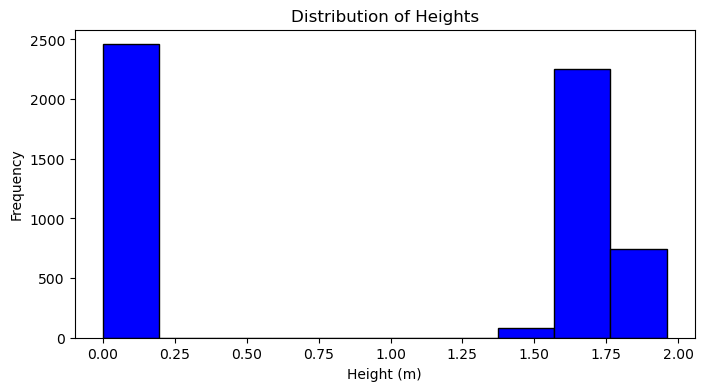

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(biometric_prediction['height'], color='blue', edgecolor='black')
plt.title('Distribution of Heights')
plt.xlabel('Height (m)')
plt.ylabel('Frequency')
plt.show()

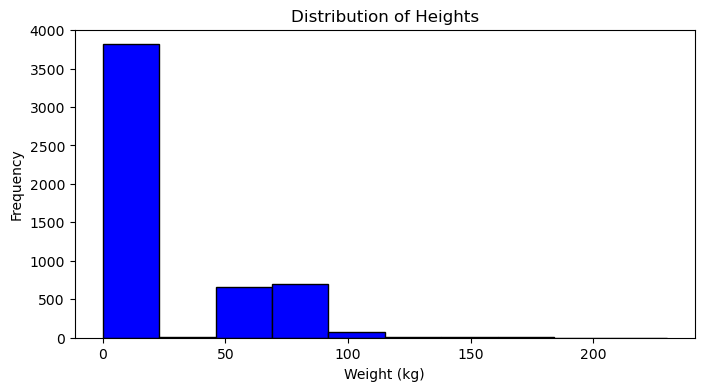

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(biometric_prediction['weight'], color='blue', edgecolor='black')
plt.title('Distribution of Heights')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.show()

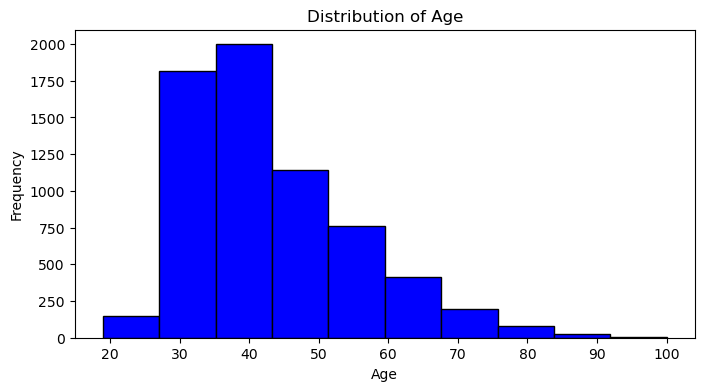

In [18]:
plt.figure(figsize=(8, 4))
plt.hist(biometric_prediction['age'], color='blue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [19]:
biometric_prediction['distinguishing_marks'].unique()

array([nan,
       'DNA profile of family members available from NCB upon request',
       'Weight about 75 kg, slim figure, height 175-180 cm; tattoo with “LOGO” FC BARCELONA SPORTS CLUB, dark hair can be dyed in light blonde, brown eye',
       'TATTOO OF A SKULL ON RIGHT ARM, TATTOO ON CHEST',
       'a scarf on his right side', 'left index finger deformed',
       'ISLAM may wear corrective lenses.',
       'TATUAJES ALUSIVOS A LA MARA SALVATRUCHA EN AMBOS BRAZOS',
       'NYABI possibly has tattoos on his right groin and left upper arm. Possibly the word " MARTHA". he has a scar on his right eyebrow and a mole on his collarbone.',
       'MARTINEZ may weigh between 77 and 159 kilograms, his black or brown hair is balding, the skin on his head may be discolored, and he may wear a hat to conceal the discolored skin.',
       'Wears a large beard, characterized as sly, prudent, religious man._x000D_\nHas a scar from wound allegedly on the right arm.',
       'Mole on left side of his

## Base Model - Logistic Regression
* Synthetic data generated (300 rows)
* Without "distinguishing marks" column

In [20]:
synthetic_train = pd.read_csv('data/synthetic_sanction_matches_v3.csv')

In [24]:
synthetic_train['client_input_dob'] = pd.to_datetime(synthetic_train['client_input_dob'])
synthetic_train[]
synthetic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   client_input_name            300 non-null    object        
 1   client_input_dob             292 non-null    datetime64[ns]
 2   client_input_nationality     293 non-null    object        
 3   ref_name                     300 non-null    object        
 4   ref_forename                 300 non-null    object        
 5   ref_dob                      291 non-null    object        
 6   ref_nationality              293 non-null    object        
 7   is_match                     300 non-null    int64         
 8   match_type                   300 non-null    object        
 9   client_input_weight          235 non-null    float64       
 10  client_input_eyes_colors_id  118 non-null    object        
 11  client_input_sex_id          300 non-null    

In [25]:
synthetic_train # see if can create standardised synthetic (for all)

,client_input_name,client_input_dob,client_input_nationality,ref_name,ref_forename,ref_dob,ref_nationality,is_match,match_type,client_input_weight,client_input_eyes_colors_id,client_input_sex_id,client_input_hairs_id,client_input_height,ref_weight,ref_eyes_colors_id,ref_sex_id,ref_hairs_id,ref_height
0,MINAS KHACHUMYAN,1984-11-05,RU,KHACHUMYAN,MINAS,1984-11-05 00:00:00,RU,1,fuzzy_match,NaN,NaN,M,OTHD,1.80,NaN,NaN,M,OTHD,1.75
1,JUAN CARLOS CASTILLO RODRIGUEZ,1994-04-25,SV,MORAN ACOSTA,HECTOR NEFTALY,1992-10-07 00:00:00,SV,0,hard_non_match,72.00,NaN,M,NaN,1.69,70.0,BLA,M,BLA,1.70
2,MAGOMED KAZI,1987-11-18,IN,KAZI,NAZIMODIN BURHANUDIN,1971-12-24 00:00:00,IN,0,near_miss_surname,0.00,NaN,M,NaN,0.00,79.0,BRO,M,BLA,0.00
3,ER TUNCAY,1969-02-02,TR,ER,TUNCAY,1969-02-02 00:00:00,TR,1,fuzzy_match,0.00,NaN,M,NaN,0.00,0.0,NaN,M,NaN,0.00
4,ALVARO OSIRIS ACOSTA BUSTILLN,1978-02-01,GT,ACOSTA BUSTILLO,ALVARO OSIRIS,1978-02-01 00:00:00,GT,1,fuzzy_match,89.69,BRO,M,NaN,1.71,86.0,BRO,M,NaN,1.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,DAVOR ELEZ,1977-01-09,BA,AZDULAEV,SULEIMAN,1971-09-13 00:00:00,RU,0,hard_non_match,90.00,OTHD,M,OTHD,1.80,NaN,NaN,M,NaN,NaN
296,RAGIM SEFIBEKOV,1988-08-31,RU,LATIF,QASIM,1983-10-01 00:00:00,PK,0,hard_non_match,0.00,BLU,M,BROF,1.70,60.0,BLA,M,BLA,1.69
297,JORGE ALBERTO AYALA,1980-02-19,SV,AYALA,YURVIN AMERICA,1990-12-05 00:00:00,SV,0,near_miss_surname,71.00,OTHD,M,BLA,1.68,NaN,NaN,F,NaN,NaN
298,WILBER SAMUEL REYES REYES,1990-09-18,SV,REYES REYES,WILBER SAMUEL,1990-09-18 00:00:00,SV,1,exact_match,74.00,BLA,M,BLA,1.60,74.0,BLA,M,BLA,1.60


In [31]:
synthetic_train['is_match'].value_counts() # make match lesser than non-match

is_match
1    150
0    150
Name: count, dtype: int64